In [2]:
!nvidia-smi


Sun Nov 30 16:15:29 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# ===========================
# TAHAP 1 — PERSIAPAN DATASET
# ===========================
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# ===========================
# Fungsi preprocessing teks
# ===========================
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+|https\S+', '', text)  # hapus URL
    text = re.sub(r'@\w+', '', text)                        # hapus mention
    text = re.sub(r'\s+', ' ', text).strip()               # hapus spasi ekstra
    return text

# ===========================
# Load dataset
# ===========================
INPUT_PATH = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/Label_berita_New.csv"

if INPUT_PATH.endswith('.csv') or INPUT_PATH.endswith('.txt'):
    df = pd.read_csv(INPUT_PATH, dtype=str, encoding='utf-8', low_memory=False)
elif INPUT_PATH.endswith('.tsv'):
    df = pd.read_csv(INPUT_PATH, sep='\t', dtype=str, encoding='utf-8', low_memory=False)
elif INPUT_PATH.endswith('.xlsx') or INPUT_PATH.endswith('.xls'):
    df = pd.read_excel(INPUT_PATH, dtype=str)
else:
    raise ValueError("Format file tidak dikenali. Gunakan .csv/.tsv/.xlsx")

# ===========================
# Pastikan kolom 'isi' & 'label' ada
# ===========================
required = {'isi', 'label'}
col_map = {c.lower(): c for c in df.columns}
missing = required - set(col_map.keys())
if missing:
    raise ValueError(f"File harus memiliki kolom: {', '.join(required)}. Kolom yang hilang: {', '.join(missing)}")
df = df.rename(columns={col_map['isi']: 'isi', col_map['label']: 'label'})

# Drop null
df = df.dropna(subset=['isi', 'label']).reset_index(drop=True)

# ===========================
# Preprocessing teks
# ===========================
df['clean_isi'] = df['isi'].apply(clean_text)
print("\nContoh preprocessing:")
print(df[['isi', 'clean_isi']].head(5).to_string(index=False))

# ===========================
# Konversi label ke integer
# ===========================
df['label'], uniques = pd.factorize(df['label'])
label2id = {u: i for i, u in enumerate(uniques)}
id2label = {i: u for u, i in label2id.items()}

print("\nMapping label -> integer:")
for k, v in label2id.items():
    print(f"{v} -> {k}")

# ===========================
# Oversampling kelas minoritas
# ===========================
max_count = df['label'].value_counts().max()
dfs = []
for label in df['label'].unique():
    class_df = df[df['label'] == label]
    if len(class_df) < max_count:
        class_df = resample(class_df, replace=True, n_samples=max_count, random_state=42)
    dfs.append(class_df)
df_balanced = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
print("\nDistribusi label setelah oversampling:")
print(df_balanced['label'].value_counts())

# ===========================
# Stratified split
# ===========================
RND = 42
train_df, temp_df = train_test_split(
    df_balanced,
    test_size=0.20,
    stratify=df_balanced['label'],
    random_state=RND
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=RND
)

print("\nUkuran split:")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# ===========================
# Simpan hasil
# ===========================
SAVE_PATH = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/"
train_df.to_csv(SAVE_PATH + "train.csv", index=False, encoding='utf-8')
val_df.to_csv(SAVE_PATH + "val.csv", index=False, encoding='utf-8')
test_df.to_csv(SAVE_PATH + "test.csv", index=False, encoding='utf-8')

print("\n[SUKSES] Dataset siap digunakan (kolom 'isi', 'clean_isi', 'label' integer).")



Contoh preprocessing:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [31]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd

MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 128

# ===========================
# Load tokenizer
# ===========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print("Tokenizer loaded ✅ —", tokenizer.__class__)
print("Vocabulary size:", tokenizer.vocab_size)

# ===========================
# Load dataset train untuk num_labels
# ===========================
TRAIN_PATH = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/train.csv"
train_df = pd.read_csv(TRAIN_PATH)

# Pastikan label integer konsisten
if train_df['label'].dtype != 'int64' and train_df['label'].dtype != 'int32':
    train_df['label'] = train_df['label'].astype(int)

num_labels = train_df["label"].nunique()
print("Number of labels:", num_labels)

# ===========================
# Load model
# ===========================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    problem_type="single_label_classification",  # pastikan untuk klasifikasi multi-class
)
print("Model loaded ✅ — siap untuk fine-tuning")

# ===========================
# Opsional: tampilkan konfigurasi
# ===========================
print("Model config:")
print(model.config)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Tokenizer loaded ✅ — <class 'transformers.models.bert.tokenization_bert_fast.BertTokenizerFast'>
Vocabulary size: 30521
Number of labels: 3


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded ✅ — siap untuk fine-tuning
Model config:
BertConfig {
  "_name_or_path": "indobenchmark/indobert-base-p1",
  "_num_labels": 5,
  "architectures": [
    "BertModel"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "problem_type": "single_label_classificati

In [33]:
# ===========================
# 1) Import library
# ===========================
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import DataCollatorWithPadding
import pandas as pd
import numpy as np

# ===========================
# 2) Hyperparameter
# ===========================
MAX_LENGTH = 128
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ===========================
# 3) Paths dataset
# ===========================
TRAIN_PATH = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/train.csv"
VAL_PATH   = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/val.csv"
TEST_PATH  = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/test.csv"

# ===========================
# 4) Load CSV
# ===========================
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

# Pastikan label integer
train_df['label'] = train_df['label'].astype(int)
val_df['label']   = val_df['label'].astype(int)
test_df['label']  = test_df['label'].astype(int)

# ===========================
# 5) Fungsi tokenisasi batch
# ===========================
def tokenize_batch(texts):
    return tokenizer(
        texts,
        max_length=MAX_LENGTH,
        padding='max_length',  # batch training tetap max_length
        truncation=True,
        return_tensors="pt"
    )

train_encodings = tokenize_batch(train_df['clean_isi'].tolist())
val_encodings   = tokenize_batch(val_df['clean_isi'].tolist())
test_encodings  = tokenize_batch(test_df['clean_isi'].tolist())

# ===========================
# 6) Dataset class PyTorch
# ===========================
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_dataset = TextDataset(train_encodings, train_df['label'].tolist())
val_dataset   = TextDataset(val_encodings, val_df['label'].tolist())
test_dataset  = TextDataset(test_encodings, test_df['label'].tolist())

print("Dataset siap ✅ — train/val/test")

# ===========================
# 7) Weighted Sampler untuk kelas minoritas
# ===========================
class_counts = train_df['label'].value_counts().sort_index()
class_weights = 1.0 / class_counts
samples_weight = train_df['label'].map(class_weights).values
samples_weight = torch.tensor(samples_weight, dtype=torch.double)
weighted_sampler = WeightedRandomSampler(weights=samples_weight, num_samples=len(samples_weight), replacement=True)
print("Weighted sampler digunakan untuk mengatasi kelas minoritas ✅")

# ===========================
# 8) DataCollator (dynamic padding)
# ===========================
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding='longest')

# ===========================
# 9) DataLoader
# ===========================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,  # gunakan sampler untuk balancing
    collate_fn=data_collator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

print("DataLoader siap ✅ — batch_size =", BATCH_SIZE)


Device: cuda
Dataset siap ✅ — train/val/test
Weighted sampler digunakan untuk mengatasi kelas minoritas ✅
DataLoader siap ✅ — batch_size = 16


In [34]:
# ===========================
# 4) Setup Fine-Tuning (with weighted loss & longer epochs)
# ===========================
import torch
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from tqdm import tqdm

# ---------------------------
# Device
# ---------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------------------
# Load model
# ---------------------------
MODEL_NAME = "indobenchmark/indobert-base-p1"
num_labels = train_df['label'].nunique()

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)
model.to(DEVICE)
print("Model siap untuk fine-tuning ✅")

# ---------------------------
# Freeze 2 layer awal
# ---------------------------
for name, param in model.named_parameters():
    if "encoder.layer.0." in name or "encoder.layer.1." in name:
        param.requires_grad = False
print("[INFO] Layer 0 & 1 frozen untuk efisiensi")

# ---------------------------
# Compute class weights (minority handling)
# ---------------------------
class_counts = train_df['label'].value_counts().sort_index()
class_weights = 1.0 / class_counts
weights = torch.tensor(class_weights.values, dtype=torch.float).to(DEVICE)
print("Class weights untuk loss function:", weights)

# ---------------------------
# Optimizer & Scheduler
# ---------------------------
EPOCHS = 5  # bisa 5–10
TOTAL_STEPS = len(train_loader) * EPOCHS
WARMUP_STEPS = int(0.06 * TOTAL_STEPS)  # 6% warmup

# Optimizer hanya untuk parameter yang requires_grad=True
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_STEPS
)

# ---------------------------
# Mixed Precision (AMP)
# ---------------------------
scaler = torch.cuda.amp.GradScaler()

# ---------------------------
# Optional: torch.compile speed boost
# ---------------------------
if hasattr(torch, "compile"):
    model = torch.compile(model)
    print("[INFO] torch.compile aktif untuk speed boost")

# ---------------------------
# Custom loss dengan class weights
# ---------------------------
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

# ---------------------------
# Training loop
# ---------------------------
for epoch in range(EPOCHS):
    model.train()
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch in loop:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(**batch)
            logits = outputs.logits
            loss = loss_fn(logits, batch['labels'])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        loop.set_postfix(loss=loss.item())

print("Fine-tuning selesai ✅")


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model siap untuk fine-tuning ✅
[INFO] Layer 0 & 1 frozen untuk efisiensi
Class weights untuk loss function: 

/tmp/ipython-input-3609956569.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


tensor([0.0005, 0.0005, 0.0005], device='cuda:0')
[INFO] torch.compile aktif untuk speed boost


Epoch 1/5:   0%|          | 0/348 [00:00<?, ?it/s]/tmp/ipython-input-3609956569.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 5/5: 100%|██████████| 348/348 [00:48<00:00,  7.19it/s, loss=0.0133]

Fine-tuning selesai ✅


In [35]:
# ===========================
# 5) Training Loop Lengkap (dengan weighted loss)
# ===========================
import torch
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import os

# ---------------------------
# Hyperparameters
# ---------------------------
EPOCHS = 5
PATIENCE = 2  # early stopping
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# Compute class weights
# ---------------------------
class_counts = train_df['label'].value_counts().sort_index()
class_weights = 1.0 / class_counts
weights = torch.tensor(class_weights.values, dtype=torch.float).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

# ---------------------------
# Optimizer & Scheduler
# ---------------------------
TOTAL_STEPS = len(train_loader) * EPOCHS
WARMUP_STEPS = int(0.06 * TOTAL_STEPS)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=TOTAL_STEPS)
scaler = torch.amp.GradScaler()  # Mixed Precision

# ---------------------------
# Early Stopping
# ---------------------------
best_val_loss = float('inf')
patience_counter = 0
CHECKPOINT_PATH = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/best_model.pt"

# ---------------------------
# Training Loop
# ---------------------------
for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    train_losses = []
    loop = tqdm(train_loader, desc=f"[Epoch {epoch+1}/{EPOCHS}] Training")

    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"):
            outputs = model(**batch)
            logits = outputs.logits
            loss = loss_fn(logits, batch['labels'])

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_losses.append(loss.item())
        loop.set_postfix(loss=loss.item())

    avg_train_loss = sum(train_losses)/len(train_losses)

    # --- VALIDATION ---
    model.eval()
    val_losses = []
    val_preds, val_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(**batch)
                logits = outputs.logits
                loss = loss_fn(logits, batch['labels'])

            val_losses.append(loss.item())
            val_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
            val_labels.extend(batch['labels'].cpu().numpy())

    avg_val_loss = sum(val_losses)/len(val_losses)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"\nEpoch {epoch+1} summary:")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # --- Early Stopping & Checkpoint ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"[INFO] Checkpoint disimpan ✅ ({CHECKPOINT_PATH})")
    else:
        patience_counter += 1
        print(f"[INFO] Patience counter: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("[INFO] Early stopping triggered 🚨")
            break

print("Training selesai ✅")
print(f"Model terbaik tersimpan di: {CHECKPOINT_PATH}")


[Epoch 1/5] Training: 100%|██████████| 348/348 [00:49<00:00,  7.00it/s, loss=0.0272]



Epoch 1 summary:
Train Loss: 0.1078 | Val Loss: 0.7537 | Val Acc: 0.7989
[INFO] Checkpoint disimpan ✅ (/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/best_model.pt)


[Epoch 2/5] Training: 100%|██████████| 348/348 [00:50<00:00,  6.84it/s, loss=0.0523]



Epoch 2 summary:
Train Loss: 0.0944 | Val Loss: 0.6802 | Val Acc: 0.8218
[INFO] Checkpoint disimpan ✅ (/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/best_model.pt)


[Epoch 3/5] Training: 100%|██████████| 348/348 [00:50<00:00,  6.86it/s, loss=0.0155]



Epoch 3 summary:
Train Loss: 0.0399 | Val Loss: 0.8447 | Val Acc: 0.8261
[INFO] Patience counter: 1/2


[Epoch 4/5] Training: 100%|██████████| 348/348 [00:48<00:00,  7.20it/s, loss=0.00227]



Epoch 4 summary:
Train Loss: 0.0299 | Val Loss: 0.7856 | Val Acc: 0.8233
[INFO] Patience counter: 2/2
[INFO] Early stopping triggered 🚨
Training selesai ✅
Model terbaik tersimpan di: /content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/best_model.pt


In [36]:
# ===========================
# 6) Evaluasi Model
# ===========================
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import pandas as pd
import time
import os

# Pastikan device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# Load model terbaik
# ---------------------------
checkpoint_path = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/best_model.pt"
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint tidak ditemukan: {checkpoint_path}")

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
model.to(device)
print("Model terbaik berhasil di-load ✅")

# ---------------------------
# Evaluasi Kuantitatif
# ---------------------------
all_preds = []
all_labels = []

start_eval = time.time()
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())
end_eval = time.time()

accuracy = accuracy_score(all_labels, all_preds)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='macro', zero_division=0)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted', zero_division=0)

print("\n===== EVALUASI KUANTITATIF =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision_macro:.4f} | (weighted): {precision_weighted:.4f}")
print(f"Recall    (macro): {recall_macro:.4f} | (weighted): {recall_weighted:.4f}")
print(f"F1-score  (macro): {f1_macro:.4f} | (weighted): {f1_weighted:.4f}")
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, zero_division=0))

# ---------------------------
# Error Analysis
# ---------------------------
test_texts = pd.read_csv(TEST_PATH)['clean_isi'].tolist()
errors = [{"text": t, "true_label": l, "pred_label": p}
          for t, l, p in zip(test_texts, all_labels, all_preds) if l != p]

errors_df = pd.DataFrame(errors)
top20_errors = errors_df.head(20)

error_csv_path = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/top20_errors.csv"
os.makedirs(os.path.dirname(error_csv_path), exist_ok=True)
top20_errors.to_csv(error_csv_path, index=False)
print(f"\nTop 20 prediksi salah disimpan ke: {error_csv_path}")

# ---------------------------
# Runtime Metrics
# ---------------------------
# Latency inference 1 teks
sample_text = test_texts[0]
inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH
).to(device)

start_inf = time.time()
with torch.no_grad():
    _ = model(**inputs)
end_inf = time.time()
latency = (end_inf - start_inf) * 1000  # ms

# Ukuran model (MB)
model_size_MB = sum(p.numel() for p in model.parameters() if p.requires_grad) * 4 / (1024**2)

print("\n===== RUNTIME =====")
print(f"Evaluasi test set selesai dalam {end_eval-start_eval:.2f} detik")
print(f"Latency inference 1 teks: {latency:.2f} ms")
print(f"Ukuran model: {model_size_MB:.2f} MB")


Model terbaik berhasil di-load ✅

===== EVALUASI KUANTITATIF =====
Accuracy: 0.8060
Precision (macro): 0.8020 | (weighted): 0.8020
Recall    (macro): 0.8060 | (weighted): 0.8060
F1-score  (macro): 0.8028 | (weighted): 0.8028

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.80      0.79       232
           1       0.74      0.66      0.70       232
           2       0.88      0.95      0.92       232

    accuracy                           0.81       696
   macro avg       0.80      0.81      0.80       696
weighted avg       0.80      0.81      0.80       696


Top 20 prediksi salah disimpan ke: /content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/top20_errors.csv

===== RUNTIME =====
Evaluasi test set selesai dalam 4.86 detik
Latency inference 1 teks: 12.03 ms
Ukuran model: 420.64 MB


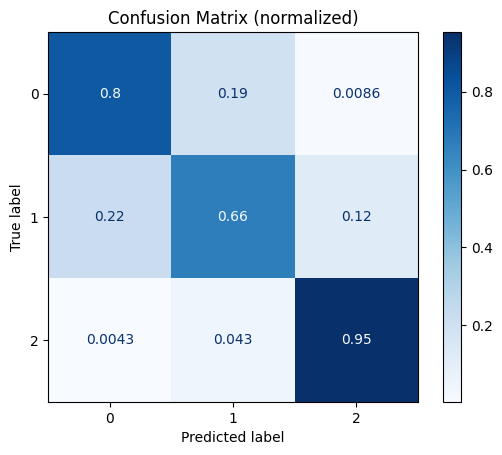

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, normalize='true', cmap='Blues')
plt.title("Confusion Matrix (normalized)")
plt.show()

In [40]:
import torch
import pickle

save_path = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/model_indobert.pkl"

model.cpu()  # pindahkan ke CPU dulu
model_dict = {
    "state_dict": model.state_dict(),
    "model_name": MODEL_NAME,
    "num_labels": num_labels
}

with open(save_path, "wb") as f:
    pickle.dump(model_dict, f)

print("Model .pkl berhasil disimpan:", save_path)


Model .pkl berhasil disimpan: /content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/model_indobert.pkl


# TRANSFER LEARNING + LoRA

In [8]:
import os
import time
import pandas as pd
import numpy as np
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)

from peft import LoraConfig, get_peft_model, TaskType, PeftModel

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# ===========================
# 2) Hyperparameters / Paths
# ===========================
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 5
PATIENCE = 2
LR = 2e-4             # LoRA biasanya pakai lr lebih besar
WEIGHT_DECAY = 0.0
LORA_R = 8
LORA_ALPHA = 32
LORA_DROPOUT = 0.1

TRAIN_PATH = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/train.csv"
VAL_PATH   = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/val.csv"
TEST_PATH  = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/test.csv"

CHECKPOINT_DIR = "/content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/best_lora"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ===========================
# 3) Tokenizer & Read CSV
# ===========================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print("Tokenizer loaded. Vocab size:", tokenizer.vocab_size)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

# ensure int labels
train_df['label'] = train_df['label'].astype(int)
val_df['label']   = val_df['label'].astype(int)
test_df['label']  = test_df['label'].astype(int)

num_labels = train_df['label'].nunique()
print("Num labels:", num_labels)

# ===========================
# 4) Tokenization (batched, keep as lists so DataCollator does padding)
# ===========================
def tokenize_texts(texts):
    # return dict of lists (no tensors) so DataCollatorWithPadding will convert to tensors
    return tokenizer(
        texts,
        max_length=MAX_LENGTH,
        truncation=True,
        padding=False,    # no padding here; collator will pad to longest in batch
        return_attention_mask=True,
        return_token_type_ids=True
    )

train_enc = tokenize_texts(train_df['clean_isi'].tolist())
val_enc   = tokenize_texts(val_df['clean_isi'].tolist())
test_enc  = tokenize_texts(test_df['clean_isi'].tolist())

# ===========================
# 5) Dataset class
# ===========================
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        # encodings: dict of lists (input_ids, attention_mask, token_type_ids possibly)
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: self.encodings[k][idx] for k in self.encodings}
        item['labels'] = int(self.labels[idx])
        return item

train_dataset = TextDataset(train_enc, train_df['label'].tolist())
val_dataset   = TextDataset(val_enc, val_df['label'].tolist())
test_dataset  = TextDataset(test_enc, test_df['label'].tolist())

# ===========================
# 6) Weighted Sampler for imbalance
# ===========================
class_counts = train_df['label'].value_counts().sort_index()
class_weights = 1.0 / class_counts
samples_weight = train_df['label'].map(class_weights).values
samples_weight = torch.tensor(samples_weight, dtype=torch.double)
weighted_sampler = WeightedRandomSampler(weights=samples_weight, num_samples=len(samples_weight), replacement=True)

# ===========================
# 7) Collator / DataLoader
# ===========================
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding='longest')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=weighted_sampler, collate_fn=data_collator)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)

print("DataLoaders ready. Batches per epoch:", len(train_loader))

# ===========================
# 8) Load base model & apply LoRA (PEFT)
# ===========================
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
# LoRA config (seq classification)
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["query", "value"],  # common for BERT-like
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

model = get_peft_model(base_model, lora_config)
model.to(DEVICE)
print("LoRA model ready. Trainable params:")
model.print_trainable_parameters()

# optional: gradient checkpointing for memory (may slightly slow)
try:
    model.gradient_checkpointing_enable()
    print("Gradient checkpointing enabled.")
except Exception:
    pass

# ===========================
# 9) Loss, Optimizer, Scheduler
# ===========================
# class weights for loss
cls_counts = train_df['label'].value_counts().sort_index()
cls_weights = torch.tensor((1.0 / cls_counts).values, dtype=torch.float).to(DEVICE)
loss_fn = torch.nn.CrossEntropyLoss(weight=cls_weights)

TOTAL_STEPS = len(train_loader) * EPOCHS
WARMUP_STEPS = int(0.06 * TOTAL_STEPS)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=TOTAL_STEPS)

scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None

# ===========================
# 10) Training loop with early stopping & save LoRA adapter
# ===========================
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} Train")
    for batch in loop:
        # move batch to device
        batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k,v in batch.items()}
        optimizer.zero_grad()

        if DEVICE.type == 'cuda':
            with torch.cuda.amp.autocast():
                outputs = model(**batch)
                loss = loss_fn(outputs.logits, batch['labels'])
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(**batch)
            loss = loss_fn(outputs.logits, batch['labels'])
            loss.backward()
            optimizer.step()

        scheduler.step()
        train_losses.append(loss.item())
        loop.set_postfix(loss=loss.item())

    avg_train_loss = np.mean(train_losses)

    # --- VALIDATION ---
    model.eval()
    val_losses = []
    val_preds, val_labels = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k,v in batch.items()}
            if DEVICE.type == 'cuda':
                with torch.cuda.amp.autocast():
                    outputs = model(**batch)
                    loss = loss_fn(outputs.logits, batch['labels'])
            else:
                outputs = model(**batch)
                loss = loss_fn(outputs.logits, batch['labels'])

            val_losses.append(loss.item())
            preds = torch.argmax(outputs.logits, dim=-1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(batch['labels'].cpu().numpy())

    avg_val_loss = np.mean(val_losses)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"\nEpoch {epoch+1} summary: TrainLoss={avg_train_loss:.4f} ValLoss={avg_val_loss:.4f} ValAcc={val_acc:.4f}")

    # checkpoint: save LoRA adapter (only)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        model.save_pretrained(CHECKPOINT_DIR)   # saves adapter files
        print(f"[INFO] LoRA adapter saved to: {CHECKPOINT_DIR}")
    else:
        patience_counter += 1
        print(f"[INFO] Patience {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("[INFO] Early stopping triggered.")
            break

print("Training finished.")

# ===========================
# 11) Evaluation / Test (load adapter + base model correctly)
# ===========================
# Load base model and attach LoRA adapter for inference
# (This is robust: load base then PeftModel.from_pretrained)
base_for_infer = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
model_for_infer = PeftModel.from_pretrained(base_for_infer, CHECKPOINT_DIR)  # loads adapter onto base
model_for_infer.to(DEVICE)
model_for_infer.eval()

all_preds = []
all_labels = []

start_eval = time.time()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k,v in batch.items()}
        if DEVICE.type == 'cuda':
            with torch.cuda.amp.autocast():
                outputs = model_for_infer(**batch)
        else:
            outputs = model_for_infer(**batch)

        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())
end_eval = time.time()

accuracy = accuracy_score(all_labels, all_preds)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)

print("\n===== Test Results =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision_macro:.4f} | (weighted): {precision_w:.4f}")
print(f"Recall    (macro): {recall_macro:.4f} | (weighted): {recall_w:.4f}")
print(f"F1-score  (macro): {f1_macro:.4f} | (weighted): {f1_w:.4f}")
print("Classification report:\n", classification_report(all_labels, all_preds, zero_division=0))

# Optional: save top errors
test_texts = pd.read_csv(TEST_PATH)['clean_isi'].tolist()
errors = [{"text": t, "true": int(l), "pred": int(p)} for t,l,p in zip(test_texts, all_labels, all_preds) if l!=p]
errors_df = pd.DataFrame(errors)
top20 = errors_df.head(20)
errors_out = os.path.join(CHECKPOINT_DIR, "top20_errors.csv")
top20.to_csv(errors_out, index=False)
print("Top errors saved to:", errors_out)

# latency & model size for adapter (approx)
sample_text = test_texts[0]
inputs = tokenizer(sample_text, return_tensors="pt", truncation=True, padding="max_length", max_length=MAX_LENGTH).to(DEVICE)
start_inf = time.time()
with torch.no_grad():
    _ = model_for_infer(**inputs)
end_inf = time.time()
latency_ms = (end_inf - start_inf) * 1000
# model size (count all params *4 bytes) — but adapter only occupies small files
total_params = sum(p.numel() for p in model_for_infer.parameters())
model_size_mb = total_params * 4 / (1024**2)
print(f"Latency (single inference): {latency_ms:.2f} ms")
print(f"Approx total params size: {model_size_mb:.2f} MB")


Device: cuda
Tokenizer loaded. Vocab size: 30521
Num labels: 3
DataLoaders ready. Batches per epoch: 348


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-466210107.py:171: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None


LoRA model ready. Trainable params:
trainable params: 297,219 || all params: 124,740,870 || trainable%: 0.2383
Gradient checkpointing enabled.


Epoch 1/5 Train:   0%|          | 0/348 [00:00<?, ?it/s]/tmp/ipython-input-466210107.py:189: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Validation:   0%|          | 0/44 [00:00<?, ?it/s]/tmp/ipython-input-466210107.py:216: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 44/44 [00:01<00:00, 26.86it/s]



Epoch 1 summary: TrainLoss=1.0769 ValLoss=1.0496 ValAcc=0.4511
[INFO] LoRA adapter saved to: /content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/best_lora


...


Epoch 4 summary: TrainLoss=1.0067 ValLoss=1.0147 ValAcc=0.4713
[INFO] LoRA adapter saved to: /content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/best_lora


Epoch 5/5 Train:   0%|          | 0/348 [00:00<?, ?it/s]/tmp/ipython-input-466210107.py:189: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Validation:   0%|          | 0/44 [00:00<?, ?it/s]/tmp/ipython-input-466210107.py:216: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validation: 100%|██████████| 44/44 [00:01<00:00, 31.70it/s]



Epoch 5 summary: TrainLoss=1.0135 ValLoss=1.0127 ValAcc=0.4727
[INFO] LoRA adapter saved to: /content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/best_lora
Training finished.


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Test:   0%|          | 0/44 [00:00<?, ?it/s]/tmp/ipython-input-466210107.py:266: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Test: 100%|██████████| 44/44 [00:01<00:00, 31.84it/s]



===== Test Results =====
Accuracy: 0.5431
Precision (macro): 0.5337 | (weighted): 0.5337
Recall    (macro): 0.5431 | (weighted): 0.5431
F1-score  (macro): 0.5344 | (weighted): 0.5344
Classification report:
               precision    recall  f1-score   support

           0       0.57      0.59      0.58       232
           1       0.46      0.35      0.40       232
           2       0.58      0.69      0.63       232

    accuracy                           0.54       696
   macro avg       0.53      0.54      0.53       696
weighted avg       0.53      0.54      0.53       696

Top errors saved to: /content/drive/MyDrive/Machine Learning/Tugas /Transfer Learning/best_lora/top20_errors.csv
Latency (single inference): 130.87 ms
Approx total params size: 475.85 MB
